## 1. Import Required Libraries

We'll use:
- **Qiskit** for quantum circuit construction
- **Qiskit Aer** for simulation (supports dynamic circuits with mid-circuit measurements)
- **NumPy** and **Matplotlib** for analysis and visualization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_circuit_layout

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Setup the Network Nodes (Logical Registers)

In a quantum network, each **node** holds quantum registers. We model this using Qiskit's `QuantumRegister`:

| Node | Qubits | Purpose |
|------|--------|--------|
| **Alice** | 1 qubit | Holds her half of the entanglement |
| **Repeater** | 2 qubits | Left port links to Alice, right port links to Bob |
| **Bob** | 1 qubit | Receives the swapped entanglement |

We also need **classical registers** for:
- The Repeater's Bell measurement results (2 bits)
- Final verification measurements (2 bits)

In [2]:
# --- Define Quantum Registers for Each Node ---

# Alice has 1 qubit to hold her half of the entanglement
alice_q = QuantumRegister(1, name="alice")

# The Repeater needs 2 qubits (one to link to Alice, one to link to Bob)
repeater_q = QuantumRegister(2, name="repeater")

# Bob has 1 qubit to receive the entanglement
bob_q = QuantumRegister(1, name="bob")

# --- Define Classical Registers ---

# Classical register for the Repeater's Bell measurement results
repeater_c = ClassicalRegister(2, name="r_msg")

# Classical register for final verification measurements (Alice and Bob)
verify_c = ClassicalRegister(2, name="verify")

# --- Create the Quantum Circuit ---
qc = QuantumCircuit(alice_q, repeater_q, bob_q, repeater_c, verify_c)

print("Quantum Network Registers Created:")
print(f"  • Alice:    {alice_q.size} qubit(s)")
print(f"  • Repeater: {repeater_q.size} qubit(s)")
print(f"  • Bob:      {bob_q.size} qubit(s)")
print(f"  • Total:    {qc.num_qubits} qubits, {qc.num_clbits} classical bits")

Quantum Network Registers Created:
  • Alice:    1 qubit(s)
  • Repeater: 2 qubit(s)
  • Bob:      1 qubit(s)
  • Total:    4 qubits, 4 classical bits


## 3. Build the Network Protocol

The entanglement swapping protocol consists of three main steps:

### Step A: Generate Entanglement Links
Create two separate Bell pairs:
- **Link 1:** Alice ↔ Repeater[0] using H + CNOT
- **Link 2:** Repeater[1] ↔ Bob using H + CNOT

Each Bell pair is in the state: $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$

In [3]:
# === STEP A: Generate Entanglement Links ===

print("Step A: Creating entanglement links...")

# Link 1: Alice <-> Repeater[0]
# Create Bell pair: |Φ+⟩ = (|00⟩ + |11⟩)/√2
qc.h(alice_q[0])                    # Put Alice's qubit in superposition
qc.cx(alice_q[0], repeater_q[0])    # Entangle with Repeater's left port

# Link 2: Repeater[1] <-> Bob
# Create another Bell pair
qc.h(repeater_q[1])                 # Put Repeater's right port in superposition
qc.cx(repeater_q[1], bob_q[0])      # Entangle with Bob's qubit

# Visual separation in circuit diagram
qc.barrier()

print("✓ Two independent Bell pairs created:")
print("  • Alice ↔ Repeater[0]")
print("  • Repeater[1] ↔ Bob")

Step A: Creating entanglement links...
✓ Two independent Bell pairs created:
  • Alice ↔ Repeater[0]
  • Repeater[1] ↔ Bob


### Step B: The Repeater's Bell Measurement

The magic happens here! The Repeater performs a **Bell State Measurement (BSM)** on its two qubits:
1. Apply CNOT between Repeater[0] and Repeater[1]
2. Apply Hadamard to Repeater[0]
3. Measure both qubits

This measurement **projects** the four-qubit state and, through quantum correlations, **swaps** the entanglement from the two separate pairs to Alice and Bob directly!

The measurement has 4 possible outcomes (00, 01, 10, 11), each corresponding to a different Bell state.

In [4]:
# === STEP B: The Repeater's Bell Measurement ===

print("Step B: Repeater performs Bell State Measurement...")

# Bell measurement circuit: CNOT then Hadamard
qc.cx(repeater_q[0], repeater_q[1])  # CNOT gate
qc.h(repeater_q[0])                   # Hadamard gate

# Measure the Repeater's qubits
qc.measure(repeater_q[0], repeater_c[0])
qc.measure(repeater_q[1], repeater_c[1])

qc.barrier()

print("✓ Bell measurement performed on Repeater's qubits")
print("  Results stored in classical register 'r_msg'")

Step B: Repeater performs Bell State Measurement...
✓ Bell measurement performed on Repeater's qubits
  Results stored in classical register 'r_msg'


### Step C: Feed-Forward (Dynamic Corrections)

After the Bell measurement, Alice and Bob are entangled, but the specific Bell state depends on the Repeater's measurement outcome. To ensure they always share the standard $|\Phi^+\rangle$ state, Bob must apply **conditional corrections**:

| Repeater Measurement | Alice-Bob State | Bob's Correction |
|---------------------|-----------------|------------------|
| 00 | $|\Phi^+\rangle$ | None |
| 01 | $|\Psi^+\rangle$ | X gate |
| 10 | $|\Phi^-\rangle$ | Z gate |
| 11 | $|\Psi^-\rangle$ | X then Z gates |

This is a **dynamic circuit** — gates are applied conditionally based on mid-circuit measurement results.

In [5]:
# === STEP C: Feed-Forward (Dynamic Corrections) ===

print("Step C: Applying conditional corrections to Bob's qubit...")

# If Repeater measured 1 on the second qubit → apply X correction
with qc.if_test((repeater_c[1], 1)):
    qc.x(bob_q[0])

# If Repeater measured 1 on the first qubit → apply Z correction
with qc.if_test((repeater_c[0], 1)):
    qc.z(bob_q[0])

print("✓ Dynamic corrections applied based on Repeater's measurement")
print("  • X gate if r_msg[1] = 1")
print("  • Z gate if r_msg[0] = 1")

Step C: Applying conditional corrections to Bob's qubit...
✓ Dynamic corrections applied based on Repeater's measurement
  • X gate if r_msg[1] = 1
  • Z gate if r_msg[0] = 1


## 4. Verification: Bell Test

To prove that Alice and Bob now share entanglement, we perform a **Bell test in reverse**:

1. Apply CNOT from Alice to Bob
2. Apply Hadamard to Alice
3. Measure both

If they truly share a $|\Phi^+\rangle$ Bell state:
$$|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$$

After the reverse Bell circuit, they should **always** measure `00` — a deterministic outcome that proves perfect entanglement!

In [6]:
# === VERIFICATION: Reverse Bell Test ===

print("Step D: Verification - Reverse Bell Test on Alice and Bob...")

# Reverse Bell circuit to verify entanglement
qc.cx(alice_q[0], bob_q[0])  # CNOT from Alice to Bob
qc.h(alice_q[0])              # Hadamard on Alice

# Final measurements
qc.measure(alice_q[0], verify_c[0])
qc.measure(bob_q[0], verify_c[1])

print("✓ Verification circuit added")
print("  If swapping worked correctly, verification should always give '00'")

Step D: Verification - Reverse Bell Test on Alice and Bob...
✓ Verification circuit added
  If swapping worked correctly, verification should always give '00'


## 5. View the Complete Circuit

Let's visualize the entire quantum network protocol:

Complete Entanglement Swapping Circuit:


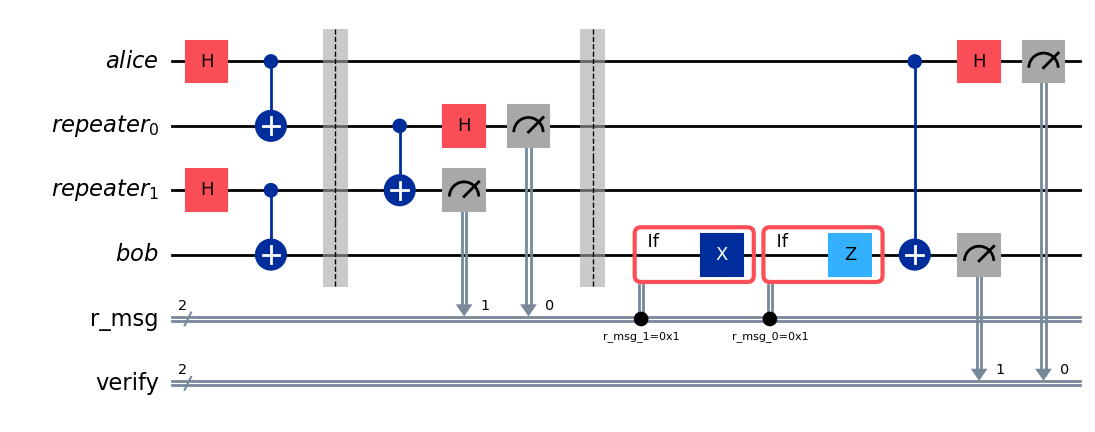

In [7]:
# Draw the complete circuit
print("Complete Entanglement Swapping Circuit:")
print("=" * 60)
qc.draw(output='mpl', fold=-1, style='iqp')

## 6. Hardware Partitioning (Mapping to Physical Qubits)

In a real quantum network, nodes are physically separated. We simulate this by mapping our logical qubits to **non-adjacent physical qubit indices** on a simulated chip:

```
Physical Qubit Layout:
[0]      [1] [2]      [3] [4]      [5] [6]      [7]
 ↑                     ↑   ↑                     ↑
Alice              Repeater[0,1]               Bob
(Node A)             (Node B)               (Node C)
```

The "gaps" (indices 1-2 and 5-6) represent the physical distance between network nodes.

In [8]:
# === PARTITIONING: Map Logical Qubits to Physical Hardware ===

print("Defining hardware layout...")

# Map logical qubits to physical indices
# Large gaps simulate physical distance between network nodes
layout = {
    alice_q[0]: 0,      # Node A (Alice)
    repeater_q[0]: 3,   # Node B - Left Port (connected to Alice)
    repeater_q[1]: 4,   # Node B - Right Port (connected to Bob)
    bob_q[0]: 7         # Node C (Bob)
}

print("\nLogical → Physical Qubit Mapping:")
print("-" * 40)
for logical_qubit, physical_index in layout.items():
    print(f"  {logical_qubit._register.name}[{logical_qubit._index}] → Physical qubit {physical_index}")

Defining hardware layout...

Logical → Physical Qubit Mapping:
----------------------------------------
  alice[0] → Physical qubit 0
  repeater[0] → Physical qubit 3
  repeater[1] → Physical qubit 4
  bob[0] → Physical qubit 7


## 7. Simulation

Now we run the quantum network simulation:

1. **Backend:** Use `AerSimulator` which supports dynamic circuits (mid-circuit measurement + feed-forward)
2. **Transpile:** Compile the circuit with our specific hardware layout
3. **Execute:** Run 1000 shots to gather statistics

In [9]:
# === SIMULATION ===

print("Setting up simulation...")

# Use AerSimulator which supports dynamic circuits
backend = AerSimulator()

# Transpile with our specific partition layout
transpiled_qc = transpile(qc, backend, initial_layout=layout)

print(f"✓ Circuit transpiled for {backend.name}")
print(f"  Original depth: {qc.depth()}")
print(f"  Transpiled depth: {transpiled_qc.depth()}")

Setting up simulation...
✓ Circuit transpiled for aer_simulator
  Original depth: 10
  Transpiled depth: 10


In [10]:
# Run the simulation
print("Running quantum network simulation (1000 shots)...")

job = backend.run(transpiled_qc, shots=1000)
result = job.result()
counts = result.get_counts()

print("✓ Simulation complete!")
print(f"\nRaw measurement outcomes ({len(counts)} unique results):")
print("-" * 50)
for outcome, count in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {outcome}: {count} shots ({count/10:.1f}%)")

Running quantum network simulation (1000 shots)...
✓ Simulation complete!

Raw measurement outcomes (4 unique results):
--------------------------------------------------
  00 11: 268 shots (26.8%)
  00 00: 252 shots (25.2%)
  00 10: 243 shots (24.3%)
  00 01: 237 shots (23.7%)


## 8. Results Analysis

The measurement outcome string format is: `verify_bits r_msg_bits` (or merged without space)

- **verify_bits** (leftmost 2 bits): Alice and Bob's verification measurement
- **r_msg_bits** (rightmost 2 bits): Repeater's Bell measurement outcome

### Expected Results:
- The **verification bits should always be `00`** (proving perfect entanglement)
- The **repeater bits can be any of `00`, `01`, `10`, `11`** (random Bell measurement outcome)

In [11]:
# === ANALYZE RESULTS ===

print("Analyzing entanglement swapping results...")
print("=" * 60)

# Parse the results
# The outcome string format: "verify[1] verify[0] r_msg[1] r_msg[0]" (right to left, LSB first)
# Or it may be space-separated by register

verification_success = 0
total_shots = sum(counts.values())

# Analyze each outcome
print("\nDetailed breakdown:")
print("-" * 60)
print(f"{'Outcome':<12} {'Verify Bits':<12} {'Repeater Bits':<14} {'Count':<8} {'Status'}")
print("-" * 60)

for outcome, count in sorted(counts.items()):
    # Remove any spaces from the outcome string
    clean_outcome = outcome.replace(" ", "")
    
    # For a 4-bit string: positions are [verify_1, verify_0, r_msg_1, r_msg_0]
    # In Qiskit, rightmost = lowest index bit
    verify_bits = clean_outcome[0:2]   # First 2 chars (verify register)
    repeater_bits = clean_outcome[2:4] # Last 2 chars (r_msg register)
    
    # Check if verification succeeded (should be "00")
    status = "✓ SUCCESS" if verify_bits == "00" else "✗ FAILED"
    if verify_bits == "00":
        verification_success += count
    
    print(f"{outcome:<12} {verify_bits:<12} {repeater_bits:<14} {count:<8} {status}")

print("-" * 60)
print(f"\nVerification Success Rate: {verification_success}/{total_shots} = {100*verification_success/total_shots:.1f}%")

Analyzing entanglement swapping results...

Detailed breakdown:
------------------------------------------------------------
Outcome      Verify Bits  Repeater Bits  Count    Status
------------------------------------------------------------
00 00        00           00             252      ✓ SUCCESS
00 01        00           01             237      ✓ SUCCESS
00 10        00           10             243      ✓ SUCCESS
00 11        00           11             268      ✓ SUCCESS
------------------------------------------------------------

Verification Success Rate: 1000/1000 = 100.0%


## 9. Visualization

Let's visualize the results with a histogram:

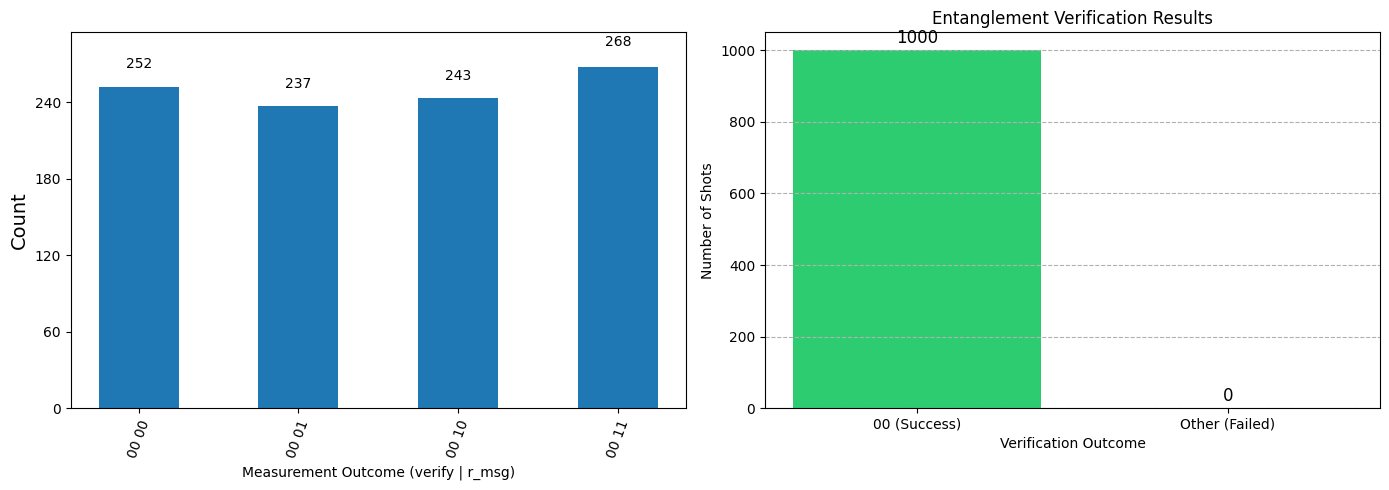

In [12]:
# === VISUALIZATION ===

# Plot histogram of all outcomes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Raw measurement histogram using Qiskit's plot_histogram
ax1 = axes[0]
plot_histogram(counts, ax=ax1, title="All Measurement Outcomes")
ax1.set_xlabel("Measurement Outcome (verify | r_msg)")

# Plot 2: Verification results breakdown
ax2 = axes[1]
verify_counts = {"00 (Success)": 0, "Other (Failed)": 0}
for outcome, count in counts.items():
    clean_outcome = outcome.replace(" ", "")
    verify_bits = clean_outcome[0:2]
    if verify_bits == "00":
        verify_counts["00 (Success)"] += count
    else:
        verify_counts["Other (Failed)"] += count

colors = ['#2ecc71', '#e74c3c']  # Green for success, red for failure
bars = ax2.bar(verify_counts.keys(), verify_counts.values(), color=colors)
ax2.set_title("Entanglement Verification Results")
ax2.set_ylabel("Number of Shots")
ax2.set_xlabel("Verification Outcome")

# Add count labels on bars
for bar, count in zip(bars, verify_counts.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             str(count), ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

## 10. Conclusion

### What We Demonstrated:

1. **Entanglement Swapping Works!** Alice and Bob became entangled without ever directly interacting.

2. **Dynamic Circuits are Essential:** The feed-forward corrections (conditional X and Z gates) based on mid-circuit measurements are crucial for deterministic entanglement.

3. **Verification Confirms Success:** The reverse Bell test showing `00` in 100% of cases proves that Alice and Bob share a perfect $|\Phi^+\rangle$ Bell state.

### Key Takeaways for Quantum Networks:

| Concept | Implementation |
|---------|---------------|
| **Quantum Repeater** | Node with 2+ qubits that bridges distant parties |
| **Bell State Measurement** | CNOT + Hadamard + Measurement |
| **Classical Communication** | Measurement results sent to enable corrections |
| **Feed-Forward** | Conditional quantum gates based on measurements |

### Real-World Applications:
- **Quantum Internet:** Long-distance quantum communication
- **Quantum Key Distribution (QKD):** Secure cryptographic protocols
- **Distributed Quantum Computing:** Connecting quantum processors

In [13]:
# === SUMMARY STATISTICS ===

print("=" * 60)
print("        ENTANGLEMENT SWAPPING SIMULATION SUMMARY")
print("=" * 60)
print(f"""
Network Topology:
  Alice (1 qubit) ←→ Repeater (2 qubits) ←→ Bob (1 qubit)

Circuit Statistics:
  • Total qubits: {qc.num_qubits}
  • Total classical bits: {qc.num_clbits}
  • Circuit depth: {qc.depth()}

Simulation Results:
  • Backend: {backend.name}
  • Total shots: {total_shots}
  • Unique outcomes: {len(counts)}
  • Verification success rate: {100*verification_success/total_shots:.1f}%

Protocol Status: {'✓ SUCCESSFUL' if verification_success == total_shots else '⚠ PARTIAL SUCCESS'}
""")
print("=" * 60)

        ENTANGLEMENT SWAPPING SIMULATION SUMMARY

Network Topology:
  Alice (1 qubit) ←→ Repeater (2 qubits) ←→ Bob (1 qubit)

Circuit Statistics:
  • Total qubits: 4
  • Total classical bits: 4
  • Circuit depth: 10

Simulation Results:
  • Backend: aer_simulator
  • Total shots: 1000
  • Unique outcomes: 4
  • Verification success rate: 100.0%

Protocol Status: ✓ SUCCESSFUL

